# 2-Stage Dist GCN + GRU Model
Distance-based adjacency (haversine KNN) with a two-stage prediction head:
- **Classifier head**: predicts demand direction (negative / zero / positive)
- **Regressor head**: predicts demand magnitude in log-transformed space

Regression target: `y_mag = log1p(|y|)`  
Classification target: 0 = negative, 1 = zero, 2 = positive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os

WORK_DIR = '/content/drive/MyDrive/DL_Project'
os.chdir(WORK_DIR)
print('cwd:', os.getcwd())

Mounted at /content/drive
cwd: /content/drive/.shortcut-targets-by-id/1cv6g42seKHWos13nKtt695z3yVVUNFOn/DL_Project


In [2]:
%pip install torch_geometric scikit-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 81.9 MB/s eta 0:00:00


In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [4]:
import polars as pl
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn.conv import GCNConv

# Data Prep

In [5]:
cabi_demand = pl.read_parquet('data/cabi_master.parquet').with_columns([
    pl.col('start_station_id').cast(pl.Int64)
])

min_rows = 1000
station_counts = cabi_demand.group_by('start_station_id').agg(pl.len().alias('n_rows')).filter(pl.col('n_rows') >= min_rows)
valid_stations = set(station_counts['start_station_id'].to_list())
cabi_demand = cabi_demand.filter(pl.col('start_station_id').is_in(valid_stations))

In [6]:
station_ids = (
    cabi_demand.select('start_station_id')
    .unique()
    .sort('start_station_id')
    .get_column('start_station_id')
    .to_list()
)
station_idx_mapper = {si: i for i, si in enumerate(station_ids)}
N = len(station_ids)
print(f'N stations: {N}')

N stations: 407


# Construct Distance Adjacency
Haversine KNN with adaptive Gaussian kernel, identical to the single-stage dist model.

In [7]:
station_coords = (
    cabi_demand
    .select(['start_station_id', 'latitude', 'longitude'])
    .unique(subset='start_station_id')
    .sort('start_station_id')
    .drop_nulls()
)
lat = station_coords['latitude'].to_numpy()
lon = station_coords['longitude'].to_numpy()
print(f'coords shape: {lat.shape}')

coords shape: (407,)


In [8]:
lat_rad = np.radians(lat)
lon_rad = np.radians(lon)
dlat = lat_rad[:, None] - lat_rad[None, :]
dlon = lon_rad[:, None] - lon_rad[None, :]
R = 6371
a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat_rad[:, None]) * np.cos(lat_rad[None, :]) * np.sin(dlon / 2) ** 2
)
D = 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
print(f'D shape: {D.shape}, range: {D.min():.3f} – {D.max():.3f} km')

D shape: (407, 407), range: 0.000 – 17.792 km


In [9]:
def build_knn_adjacency(D, k=5):
    n = D.shape[0]
    A = np.zeros_like(D)
    knn_dists = []
    for i in range(n):
        neighbors = np.argsort(D[i])[1:k+1]
        knn_dists.append(D[i, neighbors])
    sigma = np.mean(knn_dists)
    print(f'adaptive sigma: {sigma:.4f} km')
    for i in range(n):
        neighbors = np.argsort(D[i])[1:k+1]
        A[i, neighbors] = np.exp(-(D[i, neighbors] ** 2) / (2 * sigma ** 2))
    A = np.maximum(A, A.T)
    return A

A = build_knn_adjacency(D, k=5)
print(f'edges per node: {(A > 0).sum(axis=1).mean():.1f} avg | total edges: {(A > 0).sum()}')

adaptive sigma: 0.5298 km
edges per node: 6.1 avg | total edges: 2478


In [10]:
rows, cols = np.where(A > 0)
edge_index = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
edge_data  = torch.tensor(A[rows, cols], dtype=torch.float)
print(f'edge_index: {edge_index.shape}, edge_data: {edge_data.shape}')

edge_index: torch.Size([2, 2478]), edge_data: torch.Size([2478])


# Build Feature Tensors

In [11]:
static_feat = [
    'n_bus_stops', 'n_metro_stations', 'n_commuter_bus', 'n_carshare',
    'n_hotels', 'n_parks', 'n_shopping', 'total_popE', 'median_hh_incomeE',
    'in_low_stress_bikeshed', 'latitude', 'longitude',
    'm5_4_bike_', 'm5_5_sidew', 'm8_3_trail', 'm8_1_urban',
]
time_feat = [
    'temp_f', 'precip_in',
    'hour', 'minute',
    'day_of_week_sin', 'day_of_week_cos',
    'week_of_year_sin', 'week_of_year_cos',
    'month',
]
all_feat = static_feat + time_feat

In [12]:
distinct_timesteps = (
    cabi_demand.select('started_at_15')
    .unique().sort('started_at_15')
    .get_column('started_at_15').to_list()
)
T = len(distinct_timesteps)
timestep_mapper = {t: i for i, t in enumerate(distinct_timesteps)}

In [13]:
n_feat = len(all_feat)
x = np.zeros((N, T, n_feat), dtype=np.float32)
y = np.zeros((N, T),         dtype=np.float32)

demand_selected = (
    cabi_demand
    .with_columns([pl.col('start_station_id').cast(pl.Int64)])
    .with_columns([
        pl.col('start_station_id').replace(station_idx_mapper).cast(pl.Int64).alias('node_idx'),
        pl.col('started_at_15').replace(timestep_mapper).cast(pl.Int64).alias('time_idx'),
    ])
    .select(['node_idx', 'time_idx', 'demand'] + all_feat)
    .drop_nulls()
)

node_idx    = demand_selected['node_idx'].to_numpy().astype(np.int64)
time_idx    = demand_selected['time_idx'].to_numpy().astype(np.int64)
feat_vals   = demand_selected.select(all_feat).to_numpy()
demand_vals = demand_selected['demand'].to_numpy()

x[node_idx, time_idx, :] = feat_vals
y[node_idx, time_idx]    = demand_vals
x = torch.tensor(x, dtype=torch.float)
y = torch.tensor(y, dtype=torch.float)

import gc
del demand_selected
gc.collect()
print(f'x: {x.shape}, y: {y.shape}')

x: torch.Size([407, 148271, 25]), y: torch.Size([407, 148271])


In [14]:
station_active = cabi_demand.group_by('start_station_id').agg([
    pl.col('started_at_15').min().alias('first_seen'),
    pl.col('started_at_15').max().alias('last_seen'),
])

mask = torch.zeros((N, T), dtype=torch.bool)
for row in station_active.iter_rows(named=True):
    nidx    = station_idx_mapper[row['start_station_id']]
    t_start = timestep_mapper[row['first_seen']]
    t_end   = timestep_mapper[row['last_seen']]
    mask[nidx, t_start:t_end+1] = True

print(f'Mask fill rate: {mask.float().mean():.2%}')

del cabi_demand, station_active
gc.collect()

Mask fill rate: 91.31%


0

In [15]:
# regression target: magnitude only (no sign) — classifier handles direction
y_mag = torch.log1p(y.abs())
print(f'y_mag range: {y_mag.min():.3f} – {y_mag.max():.3f}')

# classification target: 0=negative, 1=zero, 2=positive
y_cls = torch.zeros_like(y, dtype=torch.long)
y_cls[y > 0] = 2
y_cls[y < 0] = 0
y_cls[y == 0] = 1
counts = torch.bincount(y_cls.view(-1), minlength=3)
print(f'class counts — neg: {counts[0]:,} | zero: {counts[1]:,} | pos: {counts[2]:,}')

y_mag range: 0.000 – 3.761
class counts — neg: 6,793,637 | zero: 46,899,056 | pos: 6,653,604


# Window Slicing

In [16]:
class WindowDataset(Dataset):
    def __init__(self, x, y_reg, y_cls, mask, seq_len, horizon):
        self.x     = x
        self.y_reg = y_reg
        self.y_cls = y_cls
        self.mask  = mask
        self.seq_len = seq_len
        self.horizon = horizon
        self.n_windows = x.shape[1] - seq_len - horizon + 1

    def __len__(self):
        return self.n_windows

    def __getitem__(self, idx):
        s = idx
        e = idx + self.seq_len
        x_win     = self.x[:, s:e, :]
        y_reg_win = self.y_reg[:, e:e+self.horizon]
        y_cls_win = self.y_cls[:, e:e+self.horizon]
        m_win     = self.mask[:, e:e+self.horizon]
        return x_win, y_reg_win, y_cls_win, m_win

# Train / Val / Test Split
Sequential 70/15/15 — no shuffling to avoid leakage into the GRU.

In [17]:
from sklearn.preprocessing import StandardScaler
import joblib

seq_len         = 48
predict_horizon = 4

T_full    = x.shape[1]
train_end = int(T_full * 0.70)
val_end   = int(T_full * 0.85)

x_train_slice  = x[:, :train_end, :]
mask_train     = mask[:, :train_end]
x_train_valid  = x_train_slice[mask_train]

scaler = StandardScaler()
scaler.fit(x_train_valid.numpy())
del x_train_slice, x_train_valid
gc.collect()

x_np = x.numpy()
scaler.transform(x_np.reshape(-1, n_feat), copy=False)
x = torch.from_numpy(x_np)

joblib.dump(scaler, 'feature_scaler_dist_2stage.pkl')

train_dataset = WindowDataset(x[:, :train_end, :],        y_mag[:, :train_end],        y_cls[:, :train_end],        mask[:, :train_end],        seq_len, predict_horizon)
val_dataset   = WindowDataset(x[:, train_end:val_end, :],  y_mag[:, train_end:val_end],  y_cls[:, train_end:val_end],  mask[:, train_end:val_end],  seq_len, predict_horizon)
test_dataset  = WindowDataset(x[:, val_end:, :],           y_mag[:, val_end:],           y_cls[:, val_end:],           mask[:, val_end:],           seq_len, predict_horizon)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

# Model
Shared GCN + GRU trunk, two heads:
- **class_head**: 3 logits per (station, horizon step) — neg / zero / pos
- **reg_head**: 1 value per (station, horizon step) — magnitude in log space

In [18]:
class DistGCN_GRU_TwoStage(nn.Module):
    def __init__(self, in_features, hidden_dim, horizon, num_nodes, gru_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.horizon    = horizon
        self.gru_layers = gru_layers

        # shared trunk
        self.gcn                  = GCNConv(in_features, hidden_dim, add_self_loops=False)
        self.gcn_2                = GCNConv(hidden_dim,  hidden_dim, add_self_loops=False)
        self.skip_connection_layer = nn.Linear(in_features, hidden_dim)
        self.gru = nn.GRU(
            input_size=hidden_dim, hidden_size=hidden_dim,
            num_layers=gru_layers,
            dropout=dropout if gru_layers > 1 else 0.0,
            batch_first=True,
        )
        self.relu = nn.ReLU()

        # classifier head: 3 logits per horizon step
        self.class_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, horizon * 3),
        )
        # regressor head: 1 value per horizon step (log space)
        self.reg_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, horizon),
        )

    def _shared_trunk(self, x, edge_index, edge_attr=None):
        batch_size, N, seq_len, Fin = x.shape
        n_graphs = batch_size * seq_len
        E = edge_index.size(1)

        offsets = torch.arange(n_graphs, device=x.device) * N
        batched_ei = edge_index.unsqueeze(0).repeat(n_graphs, 1, 1)
        batched_ei = batched_ei + offsets.view(n_graphs, 1, 1)
        batched_ei = batched_ei.permute(1, 0, 2).reshape(2, n_graphs * E)

        batched_ea = edge_attr.repeat(n_graphs) if edge_attr is not None else None

        x_flat = x.permute(0, 2, 1, 3).reshape(n_graphs * N, Fin)

        h = self.relu(self.gcn(x_flat, batched_ei, batched_ea) + self.skip_connection_layer(x_flat))
        h = self.relu(self.gcn_2(h, batched_ei, batched_ea) + h)

        h = h.reshape(batch_size, seq_len, N, self.hidden_dim)
        h = h.permute(0, 2, 1, 3).reshape(batch_size * N, seq_len, self.hidden_dim)

        _, h_n = self.gru(h)
        embedding = h_n[-1].reshape(batch_size, N, self.hidden_dim)
        return embedding

    def forward(self, x, edge_index, edge_attr=None):
        batch_size = x.shape[0]
        N = x.shape[1]
        embedding = self._shared_trunk(x, edge_index, edge_attr)  # [B, N, H_dim]

        # [B, N, horizon, 3]
        class_logits = self.class_head(embedding).reshape(batch_size, N, self.horizon, 3)
        # [B, N, horizon]
        reg_out      = self.reg_head(embedding)
        return class_logits, reg_out

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DistGCN_GRU_TwoStage(
    in_features=n_feat,
    hidden_dim=128,
    horizon=predict_horizon,
    num_nodes=N,
).to(device)
print(model)

DistGCN_GRU_TwoStage(
  (gcn): GCNConv(25, 128)
  (gcn_2): GCNConv(128, 128)
  (skip_connection_layer): Linear(in_features=25, out_features=128, bias=True)
  (gru): GRU(128, 128, num_layers=2, batch_first=True, dropout=0.2)
  (relu): ReLU()
  (class_head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=12, bias=True)
  )
  (reg_head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)


# Training

In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

LAMBDA_REG = 1.0
ALPHA      = 4.0

# class weights: inverse frequency so zero class doesn't dominate
counts = torch.bincount(y_cls.view(-1), minlength=3).float()
class_weights = (counts.sum() / (3 * counts)).to(device)
print(f'class weights — neg: {class_weights[0]:.3f} | zero: {class_weights[1]:.3f} | pos: {class_weights[2]:.3f}')

def masked_weighted_mse(pred, target, mask, alpha=ALPHA):
    m = mask.to(pred.device)
    weight = 1.0 + alpha * target[m].abs()
    return ((pred[m] - target[m]) ** 2 * weight).mean()

def two_stage_loss(class_logits, reg_pred, y_mag, y_cls, mask, lambda_reg=LAMBDA_REG):
    """
    class_logits: [B, N, H, 3]
    reg_pred:     [B, N, H]   — predicted log magnitude (no sign)
    y_mag:        [B, N, H]   — log1p(|y|) targets
    y_cls:        [B, N, H]   — long 0/1/2
    mask:         [B, N, H]   — bool
    """
    mask  = mask.to(class_logits.device)
    y_mag = y_mag.to(class_logits.device)
    y_cls = y_cls.to(class_logits.device)

    cls_logits_m = class_logits[mask]   # [M, 3]
    cls_target_m = y_cls[mask]          # [M]
    cls_loss = F.cross_entropy(cls_logits_m, cls_target_m, weight=class_weights)

    reg_loss = masked_weighted_mse(reg_pred, y_mag, mask)

    total = cls_loss + lambda_reg * reg_loss
    return total, cls_loss, reg_loss

edge_index = edge_index.to(device)
edge_data  = edge_data.to(device)
print(f'edge_index: {edge_index.shape}, edge_data: {edge_data.shape}')

class weights — neg: 2.961 | zero: 0.429 | pos: 3.023
edge_index: torch.Size([2, 2478]), edge_data: torch.Size([2478])


In [ ]:
from tqdm import tqdm

epochs = 10
best_val_loss = float('inf')
CKPT = 'best_model_dist_2stage_weighted_mse.pt'

for epoch in range(epochs):
    model.train()
    tr_loss = tr_cls = tr_reg = 0.0

    for x_b, y_reg_b, y_cls_b, m_b in tqdm(train_loader, desc=f'Epoch {epoch+1:02d} Train', leave=False):
        x_b = x_b.to(device)
        optimizer.zero_grad()
        class_logits, reg_pred = model(x_b, edge_index, edge_data)
        loss, cls_loss, reg_loss = two_stage_loss(class_logits, reg_pred, y_reg_b, y_cls_b, m_b)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item(); tr_cls += cls_loss.item(); tr_reg += reg_loss.item()

    n = len(train_loader)
    tr_loss /= n; tr_cls /= n; tr_reg /= n

    model.eval()
    va_loss = va_cls = va_reg = 0.0

    with torch.no_grad():
        for x_b, y_reg_b, y_cls_b, m_b in tqdm(val_loader, desc=f'Epoch {epoch+1:02d} Val  ', leave=False):
            x_b = x_b.to(device)
            class_logits, reg_pred = model(x_b, edge_index, edge_data)
            loss, cls_loss, reg_loss = two_stage_loss(class_logits, reg_pred, y_reg_b, y_cls_b, m_b)
            va_loss += loss.item(); va_cls += cls_loss.item(); va_reg += reg_loss.item()

    n = len(val_loader)
    va_loss /= n; va_cls /= n; va_reg /= n

    scheduler.step(va_loss)

    saved = ''
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model.state_dict(), CKPT)
        saved = 'saved!'

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"LR: {optimizer.param_groups[0]['lr']:.1e} | "
        f"Train: {tr_loss:.4f} (cls {tr_cls:.4f}, reg {tr_reg:.4f}) | "
        f"Val: {va_loss:.4f} (cls {va_cls:.4f}, reg {va_reg:.4f}) | "
        f"Best: {best_val_loss:.4f} {saved}"
    )

print(f'Best Val Loss: {best_val_loss:.4f}')

Epoch 01/10 | LR: 1.0e-03 | Train: 1.2431 (cls 0.9047, reg 0.3383) | Val: 1.2163 (cls 0.8919, reg 0.3244) | Best: 1.2163 saved!


Epoch 02/10 | LR: 1.0e-03 | Train: 1.1929 (cls 0.8773, reg 0.3156) | Val: 1.1952 (cls 0.8780, reg 0.3172) | Best: 1.1952 saved!


Epoch 03/10 | LR: 1.0e-03 | Train: 1.1777 (cls 0.8667, reg 0.3110) | Val: 1.1884 (cls 0.8715, reg 0.3169) | Best: 1.1884 saved!


Epoch 04/10 | LR: 1.0e-03 | Train: 1.1664 (cls 0.8588, reg 0.3076) | Val: 1.1830 (cls 0.8671, reg 0.3160) | Best: 1.1830 saved!


Epoch 05/10 | LR: 1.0e-03 | Train: 1.1588 (cls 0.8539, reg 0.3049) | Val: 1.1803 (cls 0.8649, reg 0.3154) | Best: 1.1803 saved!


Epoch 06/10 | LR: 1.0e-03 | Train: 1.1540 (cls 0.8507, reg 0.3033) | Val: 1.1782 (cls 0.8634, reg 0.3148) | Best: 1.1782 saved!


Epoch 07/10 | LR: 1.0e-03 | Train: 1.1506 (cls 0.8484, reg 0.3021) | Val: 1.1770 (cls 0.8626, reg 0.3144) | Best: 1.1770 saved!


Epoch 08/10 | LR: 1.0e-03 | Train: 1.1482 (cls 0.8468, reg 0.3014) | Val: 1.1763 (cls 0.8623, reg 0.3141) | Best: 1.1763 saved!


Epoch 09/10 | LR: 1.0e-03 | Train: 1.1462 (cls 0.8454, reg 0.3007) | Val: 1.1761 (cls 0.8622, reg 0.3139) | Best: 1.1761 saved!


Epoch 10/10 | LR: 1.0e-03 | Train: 1.1446 (cls 0.8444, reg 0.3002) | Val: 1.1752 (cls 0.8618, reg 0.3135) | Best: 1.1752 saved!
Best Val Loss: 1.1752


# Diagnostics

In [23]:
# import matplotlib.pyplot as plt
# from scipy.stats import pearsonr

# CKPT = "best_model_dist_2stage_weighted_mse.pt"
# model.load_state_dict(torch.load(CKPT, map_location=device))
# model.eval()

# all_preds, all_targets_mag, all_targets_cls, all_masks = [], [], [], []

# with torch.no_grad():
#     for x_b, y_mag_b, y_cls_b, m_b in test_loader:
#         x_b = x_b.to(device)
#         class_logits, reg_pred = model(x_b, edge_index, edge_data)

#         class_pred = class_logits.argmax(dim=-1).cpu()
#         sign = torch.zeros_like(reg_pred.cpu())
#         sign[class_pred == 0] = -1.0
#         sign[class_pred == 2] =  1.0
#         mag_raw  = torch.exp(reg_pred.cpu().clamp(min=0)) - 1
#         combined = sign * mag_raw

#         all_preds.append(combined)
#         all_targets_mag.append(y_mag_b)
#         all_targets_cls.append(y_cls_b)
#         all_masks.append(m_b)

# preds = torch.cat(all_preds, dim=0)
# targets_mag = torch.cat(all_targets_mag, dim=0)
# targets_cls = torch.cat(all_targets_cls, dim=0)
# masks = torch.cat(all_masks, dim=0)

# true_sign = torch.zeros_like(targets_mag)
# true_sign[targets_cls == 0] = -1.0
# true_sign[targets_cls == 2] =  1.0
# targets_raw = true_sign * (torch.exp(targets_mag.clamp(min=0)) - 1)

# preds_flat = preds[masks].numpy()
# targets_flat = targets_raw[masks].numpy()

# print(f'pred min/max:   {preds_flat.min():.4f}  {preds_flat.max():.4f}')
# print(f'target min/max: {targets_flat.min():.4f}  {targets_flat.max():.4f}')

# nz = targets_flat != 0
# mae_all = np.abs(preds_flat - targets_flat).mean()
# mae_nz = np.abs(preds_flat[nz] - targets_flat[nz]).mean()
# rmse_all = np.sqrt(((preds_flat - targets_flat) ** 2).mean())
# pcp_all = (preds_flat.round() == targets_flat).mean()
# pcp_nz = (preds_flat[nz].round() == targets_flat[nz]).mean()

# actual_trip    = targets_flat != 0
# predicted_trip = preds_flat.round() != 0
# pptt = (predicted_trip == actual_trip).mean()

# print(f'MAE  (all):      {mae_all:.4f}')
# print(f'MAE  (nonzero):  {mae_nz:.4f}')
# print(f'RMSE (all):      {rmse_all:.4f}')
# print(f'PCP  (all):      {pcp_all:.4f}')
# print(f'PCP  (nonzero):  {pcp_nz:.4f}')
# print(f'PPTT:            {pptt:.4f}')

# if nz.sum() > 10:
#     corr, _ = pearsonr(preds_flat[nz], targets_flat[nz])
#     print(f'Corr (nonzero):  {corr:.4f}')

# dir_acc_all = (np.sign(preds_flat.round()) == np.sign(targets_flat)).mean()
# dir_acc_nz = (np.sign(preds_flat[nz].round()) == np.sign(targets_flat[nz])).mean()
# print(f'Direction acc (all):     {dir_acc_all:.4f}')
# print(f'Direction acc (nonzero): {dir_acc_nz:.4f}')

import matplotlib.pyplot as plt
from scipy.stats import pearsonr

CKPT = "best_model_dist_2stage_weighted_mse.pt"
model.load_state_dict(torch.load(CKPT, map_location=device))
model.eval()

all_preds, all_targets_mag, all_targets_cls, all_masks = [], [], [], []
all_probs, all_mags = [], []

with torch.no_grad():
    for x_b, y_mag_b, y_cls_b, m_b in test_loader:
        x_b = x_b.to(device)
        class_logits, reg_pred = model(x_b, edge_index, edge_data)

        probs   = F.softmax(class_logits.cpu(), dim=-1)      # [B, N, H, 3]
        mag_raw = torch.exp(reg_pred.cpu().clamp(min=0)) - 1 # [B, N, H]

        class_pred = class_logits.argmax(dim=-1).cpu()
        sign = torch.zeros_like(reg_pred.cpu())
        sign[class_pred == 0] = -1.0
        sign[class_pred == 2] =  1.0
        combined = sign * mag_raw

        all_preds.append(combined)
        all_targets_mag.append(y_mag_b)
        all_targets_cls.append(y_cls_b)
        all_masks.append(m_b)
        all_probs.append(probs)
        all_mags.append(mag_raw)

preds       = torch.cat(all_preds, dim=0)
targets_mag = torch.cat(all_targets_mag, dim=0)
targets_cls = torch.cat(all_targets_cls, dim=0)
masks       = torch.cat(all_masks, dim=0)
probs_all   = torch.cat(all_probs, dim=0)
mags_all    = torch.cat(all_mags, dim=0)

true_sign = torch.zeros_like(targets_mag)
true_sign[targets_cls == 0] = -1.0
true_sign[targets_cls == 2] =  1.0
targets_raw = true_sign * (torch.exp(targets_mag.clamp(min=0)) - 1)

preds_flat   = preds[masks].numpy()
targets_flat = targets_raw[masks].numpy()

# P(nonzero) = 1 - P(zero class), where zero = class index 1
p_flat   = (1 - probs_all[..., 1][masks]).numpy()
mag_flat = mags_all[masks].numpy()

print(f'pred min/max:   {preds_flat.min():.4f}  {preds_flat.max():.4f}')
print(f'target min/max: {targets_flat.min():.4f}  {targets_flat.max():.4f}')

nz = targets_flat != 0
mae_all = np.abs(preds_flat - targets_flat).mean()
mae_nz = np.abs(preds_flat[nz] - targets_flat[nz]).mean()
rmse_all = np.sqrt(((preds_flat - targets_flat) ** 2).mean())
pcp_all = (preds_flat.round() == targets_flat).mean()
pcp_nz = (preds_flat[nz].round() == targets_flat[nz]).mean()

actual_trip    = targets_flat != 0
predicted_trip = preds_flat.round() != 0
pptt = (predicted_trip == actual_trip).mean()

print(f'MAE  (all):      {mae_all:.4f}')
print(f'MAE  (nonzero):  {mae_nz:.4f}')
print(f'RMSE (all):      {rmse_all:.4f}')
print(f'PCP  (all):      {pcp_all:.4f}')
print(f'PCP  (nonzero):  {pcp_nz:.4f}')
print(f'PPTT:            {pptt:.4f}')

if nz.sum() > 10:
    corr, _ = pearsonr(preds_flat[nz], targets_flat[nz])
    print(f'Corr (nonzero):  {corr:.4f}')

dir_acc_all = (np.sign(preds_flat.round()) == np.sign(targets_flat)).mean()
dir_acc_nz = (np.sign(preds_flat[nz].round()) == np.sign(targets_flat[nz])).mean()
print(f'Direction acc (all):     {dir_acc_all:.4f}')
print(f'Direction acc (nonzero): {dir_acc_nz:.4f}')

pred min/max:   -5.7779  5.6682
target min/max: -20.0000  26.0000
MAE  (all):      0.5288
MAE  (nonzero):  1.3182
RMSE (all):      0.9719
PCP  (all):      0.6131
PCP  (nonzero):  0.3154
PPTT:            0.7368
Corr (nonzero):  0.2540
Direction acc (all):     0.6590
Direction acc (nonzero): 0.5023


In [ ]:
import os
import pandas as pd
from datetime import datetime

metrics = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model": "dist_2_stage_dist",
    "ckpt": CKPT,

    "pred_min": float(preds_flat.min()),
    "pred_max": float(preds_flat.max()),
    "target_min": float(targets_flat.min()),
    "target_max": float(targets_flat.max()),

    "mae_all": float(mae_all),
    "mae_nonzero": float(mae_nz),
    "rmse_all": float(rmse_all),
    "pcp_all": float(pcp_all),
    "pcp_nonzero": float(pcp_nz),
    "pptt": float(pptt),
    "corr_nonzero": float(corr) if nz.sum() > 10 else None,
    "dir_acc_all": float(dir_acc_all),
    "dir_acc_nonzero": float(dir_acc_nz),
}

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

csv_path = os.path.join(out_dir, "2_stage_dist_model_metrics.csv")

df_new = pd.DataFrame([metrics])

if os.path.exists(csv_path):
    df_old = pd.read_csv(csv_path)
    df_all = pd.concat([df_old, df_new], ignore_index=True)
else:
    df_all = df_new

df_all.to_csv(csv_path, index=False)

print(f"Saved metrics to {csv_path}")

Saved metrics to outputs/2_stage_dist_model_metrics.csv


Saved plot to outputs/pred_vs_actual_dist_2stage.png


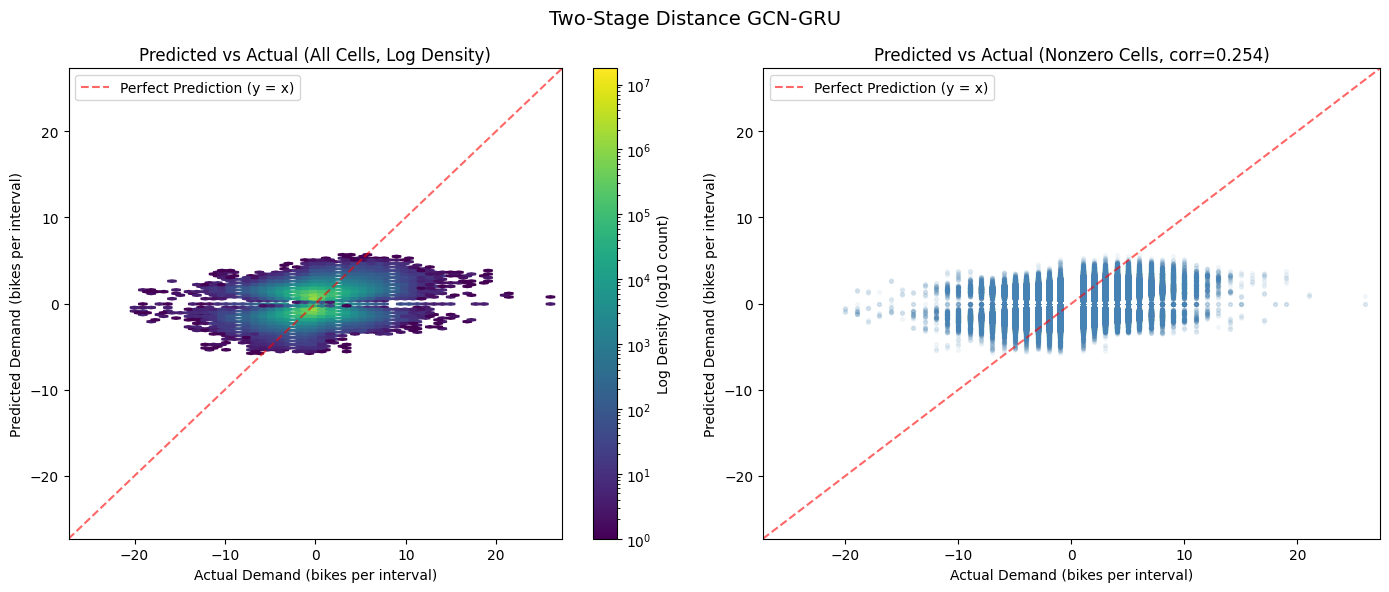

In [ ]:
import os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# overall title
fig.suptitle(
    'Two-Stage Distance GCN-GRU',
    fontsize=14
)

# ---- All cells ----
ax = axes[0]
hb = ax.hexbin(targets_flat, preds_flat, gridsize=50, bins="log", cmap="viridis", mincnt=1)

lim = max(abs(targets_flat).max(), abs(preds_flat).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], "r--", alpha=0.6, label="Perfect Prediction (y = x)")

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.set_xlabel("Actual Demand (bikes per interval)")
ax.set_ylabel("Predicted Demand (bikes per interval)")
ax.set_title("Predicted vs Actual (All Cells, Log Density)", fontsize=12)
ax.legend(loc="upper left")

plt.colorbar(hb, ax=ax, label="Log Density (log10 count)")

# ---- Nonzero cells ----
ax = axes[1]

ax.scatter(targets_flat[nz], preds_flat[nz], alpha=0.05, s=8, color="steelblue")

nz_lim = max(abs(targets_flat[nz]).max(), abs(preds_flat[nz]).max()) * 1.05
ax.plot([-nz_lim, nz_lim], [-nz_lim, nz_lim], "r--", alpha=0.6, label="Perfect Prediction (y = x)")

ax.set_xlim(-nz_lim, nz_lim)
ax.set_ylim(-nz_lim, nz_lim)

ax.set_xlabel("Actual Demand (bikes per interval)")
ax.set_ylabel("Predicted Demand (bikes per interval)")

corr, _ = pearsonr(preds_flat[nz], targets_flat[nz])
ax.set_title(f"Predicted vs Actual (Nonzero Cells, corr={corr:.3f})", fontsize=12)
ax.legend(loc="upper left")

plt.tight_layout()

save_path = os.path.join(out_dir, "pred_vs_actual_dist_2stage.png")
plt.savefig(save_path, dpi=120, bbox_inches="tight")

print(f"Saved plot to {save_path}")
plt.show()

Saved plot to outputs/residuals_dist_2stage.png


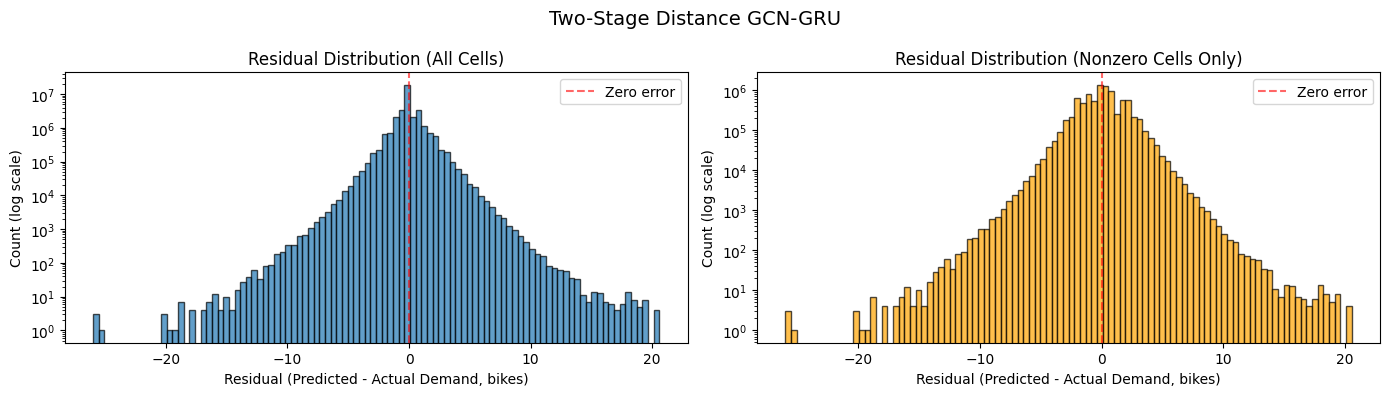

In [ ]:
import os
import matplotlib.pyplot as plt

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

residuals = preds_flat - targets_flat

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# overall title
fig.suptitle(
    'Two-Stage Distance GCN-GRU',
    fontsize=14
)

# ---- All cells ----
axes[0].hist(residuals, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Residual (Predicted - Actual Demand, bikes)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Residual Distribution (All Cells)', fontsize=12)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.6, label='Zero error')
axes[0].set_yscale('log')
axes[0].legend()

# ---- Nonzero cells ----
axes[1].hist(residuals[nz], bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Residual (Predicted - Actual Demand, bikes)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Residual Distribution (Nonzero Cells Only)', fontsize=12)
axes[1].axvline(0, color='red', linestyle='--', alpha=0.6, label='Zero error')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()

save_path = os.path.join(out_dir, "residuals_dist_2stage.png")
plt.savefig(save_path, dpi=120, bbox_inches='tight')

print(f"Saved plot to {save_path}")
plt.show()

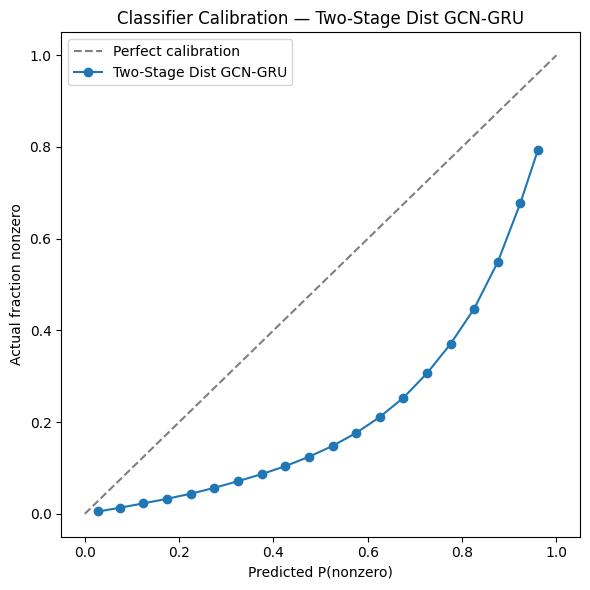

In [24]:
from sklearn.calibration import calibration_curve

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

y_binary = (targets_flat != 0).astype(int)
prob_true, prob_pred = calibration_curve(y_binary, p_flat, n_bins=20)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
plt.plot(prob_pred, prob_true, marker='o', label='Two-Stage Dist GCN-GRU')
plt.xlabel('Predicted P(nonzero)')
plt.ylabel('Actual fraction nonzero')
plt.title('Classifier Calibration: Two-Stage Dist GCN-GRU')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'classifier_calibration_dist_2stage.png'), dpi=120, bbox_inches='tight')
plt.show()